In [21]:
# ============================================================
# CELLULE 0 — Configuration globale : imports, style, palette, paths
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# ── Paths ────────────────────────────────────────────────────
BASE = Path(".")  # exécuter depuis final/A1_temporal/
DATA_A1 = BASE / "data"
DATA = BASE.parent / "data"
OUT = BASE / "outputs"
OUT.mkdir(exist_ok=True)

# ── Palette candidats ────────────────────────────────────────
COLORS = {
    "Brossat": "#E63946",  # PCF — rouge vif
    "Chikirou": "#C1121F",  # LFI — rouge sombre
    "Belliard": "#2D6A4F",  # EELV — vert
    "Gregoire": "#E07A5F",  # PS — rose saumon
    "Bournazel": "#F4A261",  # Horizons — orange
    "Dati": "#264653",  # LR — bleu foncé
    "Knafo": "#6D4C41",  # Reconquête — brun
    "Mariani": "#1D3557",  # RN — bleu marine
}

# Mapping candidate_id → clé COLORS
ID_TO_KEY = {
    "david_belliard": "Belliard",
    "emmanuel_gregoire": "Gregoire",
    "ian_brossat": "Brossat",
    "pierre_yves_bournazel": "Bournazel",
    "rachida_dati": "Dati",
    "sarah_knafo": "Knafo",
    "sophia_chikirou": "Chikirou",
    "thierry_mariani": "Mariani",
}

# Labels courts pour les graphes
SHORT_LABEL = {
    "Belliard": "Belliard\n(EELV)",
    "Gregoire": "Grégoire\n(PS)",
    "Brossat": "Brossat\n(PCF)",
    "Bournazel": "Bournazel\n(Horizons)",
    "Dati": "Dati\n(LR)",
    "Knafo": "Knafo\n(Reconquête)",
    "Chikirou": "Chikirou\n(LFI)",
    "Mariani": "Mariani\n(RN)",
}

# ── Style matplotlib global ──────────────────────────────────
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial"],
        "font.size": 11,
        "axes.titlesize": 14,
        "axes.labelsize": 11,
        "figure.dpi": 150,
        "savefig.dpi": 200,
        "savefig.bbox": "tight",
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    }
)


def swiss_style(ax, title="", subtitle="", source="", grid_axis="y"):
    """Applique le style Swiss Design à un axe matplotlib."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#CCCCCC")
    ax.spines["bottom"].set_color("#CCCCCC")
    ax.tick_params(colors="#333333", labelsize=10, length=3)
    ax.set_facecolor("white")
    ax.figure.set_facecolor("white")
    if title:
        ax.set_title(
            title, fontsize=13, fontweight="bold", loc="left", color="#1a1a1a", pad=10
        )
    if subtitle:
        ax.text(
            0,
            1.03,
            subtitle,
            transform=ax.transAxes,
            fontsize=9,
            color="#666666",
            va="bottom",
        )
    if source:
        ax.text(
            1,
            -0.13,
            source,
            transform=ax.transAxes,
            fontsize=8,
            color="#999999",
            ha="right",
            va="top",
        )
    if grid_axis:
        ax.grid(axis=grid_axis, color="#F0F0F0", linewidth=0.6, zorder=0)
    return ax


print("✓ Cellule 0 OK — Configuration chargée")
print(f"  Palette : {len(COLORS)} candidats")
print(f"  Output  : {OUT.resolve()}")

✓ Cellule 0 OK — Configuration chargée
  Palette : 8 candidats
  Output  : D:\Users\Proprietaire\Desktop\Projet_perso\Presidentielle_tracker\final\A1_temporal\outputs


In [22]:
# ============================================================
# CELLULE 1 — Chargement des données A1 + inspection
# ============================================================

DATA = Path('..') / 'data'   # final/data/ depuis A1_temporal/

# ── Chargement ───────────────────────────────────────────────
tw = pd.read_csv(DATA_A1 / "weekly_metrics_twitter.csv", parse_dates=["week_start"])
ig = pd.read_csv(DATA_A1 / "weekly_metrics_instagram.csv", parse_dates=["week_start"])
tk = pd.read_csv(DATA_A1 / "weekly_metrics_tiktok.csv", parse_dates=["week_start"])
ano = pd.read_csv(DATA_A1 / "anomalies_detected.csv", parse_dates=["week_start"])
mom = pd.read_csv(DATA_A1 / "momentum_scores.csv")
cor = pd.read_csv(DATA_A1 / "crossplatform_correlation.csv")
eco = pd.read_csv(DATA_A1 / "ecosystem_gregoire.csv", parse_dates=["week_start"])

# ── Ajout de la clé candidat pour la palette ─────────────────
for df in [tw, ig, ano, mom]:
    df["key"] = df["candidate_id"].map(ID_TO_KEY)

# ── Inspection résumée ───────────────────────────────────────
datasets = {
    "weekly_metrics_twitter": tw,
    "weekly_metrics_instagram": ig,
    "weekly_metrics_tiktok": tk,
    "anomalies_detected": ano,
    "momentum_scores": mom,
    "crossplatform_correlation": cor,
    "ecosystem_gregoire": eco,
}

print("=" * 60)
for name, df in datasets.items():
    print(f"\n▸ {name}")
    print(f"  Shape   : {df.shape}")
    print(f"  Columns : {list(df.columns)}")
    nans = df.isnull().sum()
    nans = nans[nans > 0]
    if len(nans):
        print(f"  NaN     : {nans.to_dict()}")
    else:
        print(f"  NaN     : aucun")

# ── Couverture temporelle par candidat (Twitter) ─────────────
print("\n" + "=" * 60)
print("\n▸ Couverture Twitter — semaines par candidat")
cov = (
    tw.groupby("key")
    .agg(
        n_semaines=("year_week", "count"),
        debut=("week_start", "min"),
        fin=("week_start", "max"),
        er_med_moy=("er_median", "mean"),
    )
    .sort_values("n_semaines", ascending=False)
)
print(cov.to_string())

# ── Signalement anomalie Bournazel IG momentum ───────────────
print("\n" + "=" * 60)
print("\n▸ Vérification momentum — valeurs aberrantes ?")
print(
    mom[
        ["candidate_label", "platform", "momentum_slope", "r_squared", "p_value"]
    ].to_string(index=False)
)

# ── Note sur les unités d'ER ─────────────────────────────────
print("\n" + "=" * 60)
print("\n⚠ NOTE UNITÉS")
print(
    f"  er_median Twitter (weekly) : min={tw['er_median'].min():.4f}  max={tw['er_median'].max():.4f}  → ratio décimal"
)
tweets_raw = pd.read_csv(DATA / "tweets_twitter.csv")
er_raw = tweets_raw["engagement_rate"].dropna()
print(
    f"  engagement_rate tweets bruts: min={er_raw.min():.2f}  max={er_raw.max():.2f}  → semble être en %"
)
print("  → Ces deux métriques ne sont PAS directement comparables.")
print("    A1 utilisera er_median (weekly, ratio décimal × 1000 = ‰) pour les figures.")


▸ weekly_metrics_twitter
  Shape   : (427, 13)
  Columns : ['candidate_id', 'year_week', 'er_median', 'er_mean', 'volume', 'interactions_total', 'likes_total', 'comments_total', 'shares_total', 'week_start', 'platform', 'candidate_label', 'key']
  NaN     : aucun

▸ weekly_metrics_instagram
  Shape   : (427, 13)
  Columns : ['candidate_id', 'year_week', 'er_median', 'er_mean', 'volume', 'interactions_total', 'likes_total', 'comments_total', 'shares_total', 'week_start', 'platform', 'candidate_label', 'key']
  NaN     : aucun

▸ weekly_metrics_tiktok
  Shape   : (39, 13)
  Columns : ['candidate_id', 'year_week', 'er_median', 'er_mean', 'volume', 'interactions_total', 'likes_total', 'comments_total', 'shares_total', 'week_start', 'views_median', 'platform', 'candidate_label']
  NaN     : aucun

▸ anomalies_detected
  Shape   : (70, 14)
  Columns : ['candidate_id', 'candidate_label', 'platform', 'year_week', 'week_start', 'er_median', 'z_score', 'z_global', 'z_rolling', 'anomaly_type', '

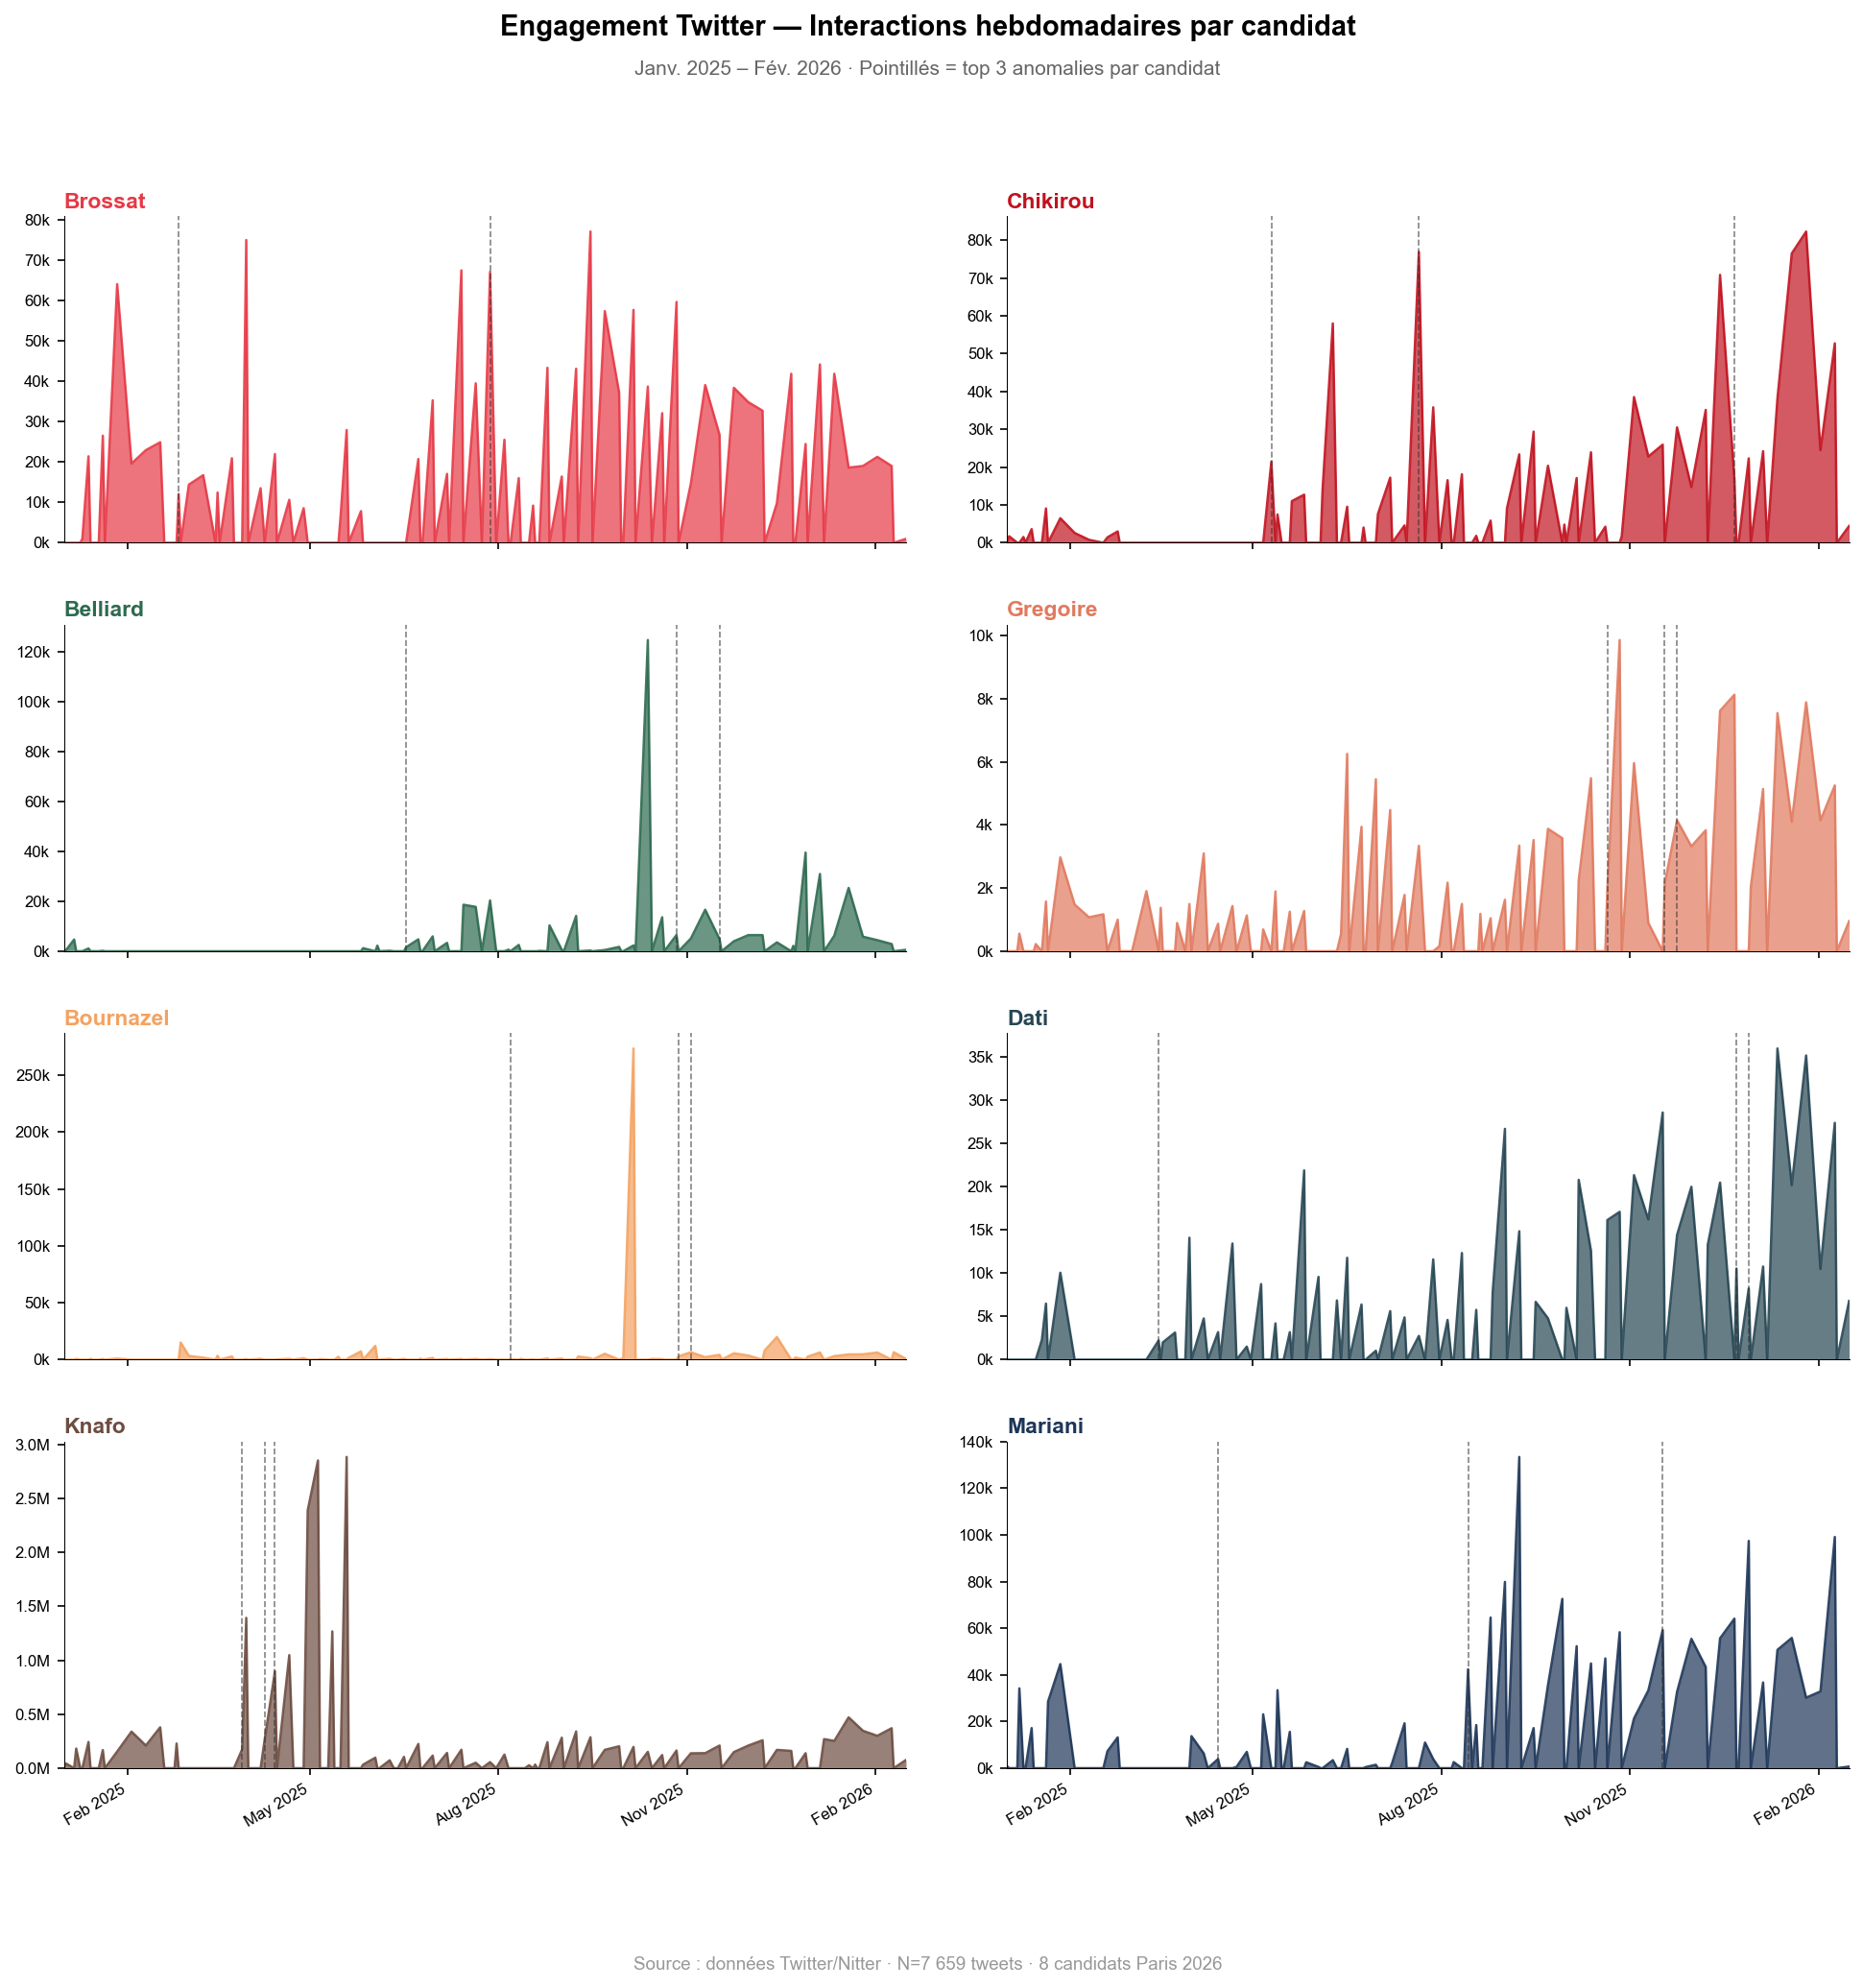

✓ Figure sauvegardée → outputs\A1_C2_timeline_engagement.png


In [23]:
# ============================================================
# CELLULE 2 — Timeline d'engagement Twitter : interactions hebdo
#             Small multiples — 1 subplot par candidat
# ============================================================

# ── Ordre des candidats : gauche → droite idéologique ────────
ORDRE = [
    "Brossat",
    "Chikirou",
    "Belliard",
    "Gregoire",
    "Bournazel",
    "Dati",
    "Knafo",
    "Mariani",
]

# ── Pivot : interactions totales par semaine × candidat ──────
pivot = (
    tw.pivot_table(
        index="week_start", columns="key", values="interactions_total", aggfunc="sum"
    )
    .reindex(columns=ORDRE)
    .fillna(0)
)

# ── Anomalies Twitter ────────────────────────────────────────
ano_tw = ano[ano["platform"] == "twitter"].copy()

# ── Figure : 4 lignes × 2 colonnes ───────────────────────────
fig, axes = plt.subplots(
    4,
    2,
    figsize=(16, 14),
    sharex=True,
    gridspec_kw={"hspace": 0.25, "wspace": 0.12},
)
axes_flat = axes.flatten()

for idx, cand in enumerate(ORDRE):
    ax = axes_flat[idx]
    vals = pivot[cand].values
    color = COLORS[cand]

    # Aire remplie
    ax.fill_between(pivot.index, 0, vals, color=color, alpha=0.7, linewidth=0)
    ax.plot(pivot.index, vals, color=color, linewidth=1.2, alpha=0.9)

    # Anomalies pour ce candidat
    cand_ano = ano_tw[ano_tw["key"] == cand].copy()
    if not cand_ano.empty:
        top_ano = cand_ano.nlargest(3, "z_global")
        for _, row in top_ano.iterrows():
            ax.axvline(
                row["week_start"],
                color="#333333",
                linewidth=0.8,
                linestyle="--",
                alpha=0.6,
                zorder=5,
            )

    # Titre du subplot
    ax.set_title(cand, fontsize=11, fontweight="bold", color=color, loc="left", pad=4)

    # Formatage axe Y (adaptatif par candidat)
    ymax = vals.max()
    if ymax >= 1e6:
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M")
        )
    elif ymax >= 1000:
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k")
        )
    else:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}"))

    # Style minimal
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.5)
    ax.spines["bottom"].set_linewidth(0.5)
    ax.tick_params(axis="both", labelsize=8)
    ax.set_xlim(pivot.index.min(), pivot.index.max())
    ax.set_ylim(0, None)

# ── Axe X : format date sur la dernière ligne ────────────────
for ax in axes_flat[-2:]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)

# ── Titre général et source ──────────────────────────────────
fig.suptitle(
    "Engagement Twitter — Interactions hebdomadaires par candidat",
    fontsize=14,
    fontweight="bold",
    y=0.98,
)
fig.text(
    0.5,
    0.95,
    "Janv. 2025 – Fév. 2026 · Pointillés = top 3 anomalies par candidat",
    ha="center",
    fontsize=10,
    color="#666666",
)
fig.text(
    0.5,
    0.01,
    "Source : données Twitter/Nitter · N=7 659 tweets · 8 candidats Paris 2026",
    ha="center",
    fontsize=9,
    color="#999999",
)

plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.savefig(OUT / "A1_C2_timeline_engagement.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"✓ Figure sauvegardée → {OUT / 'A1_C2_timeline_engagement.png'}")

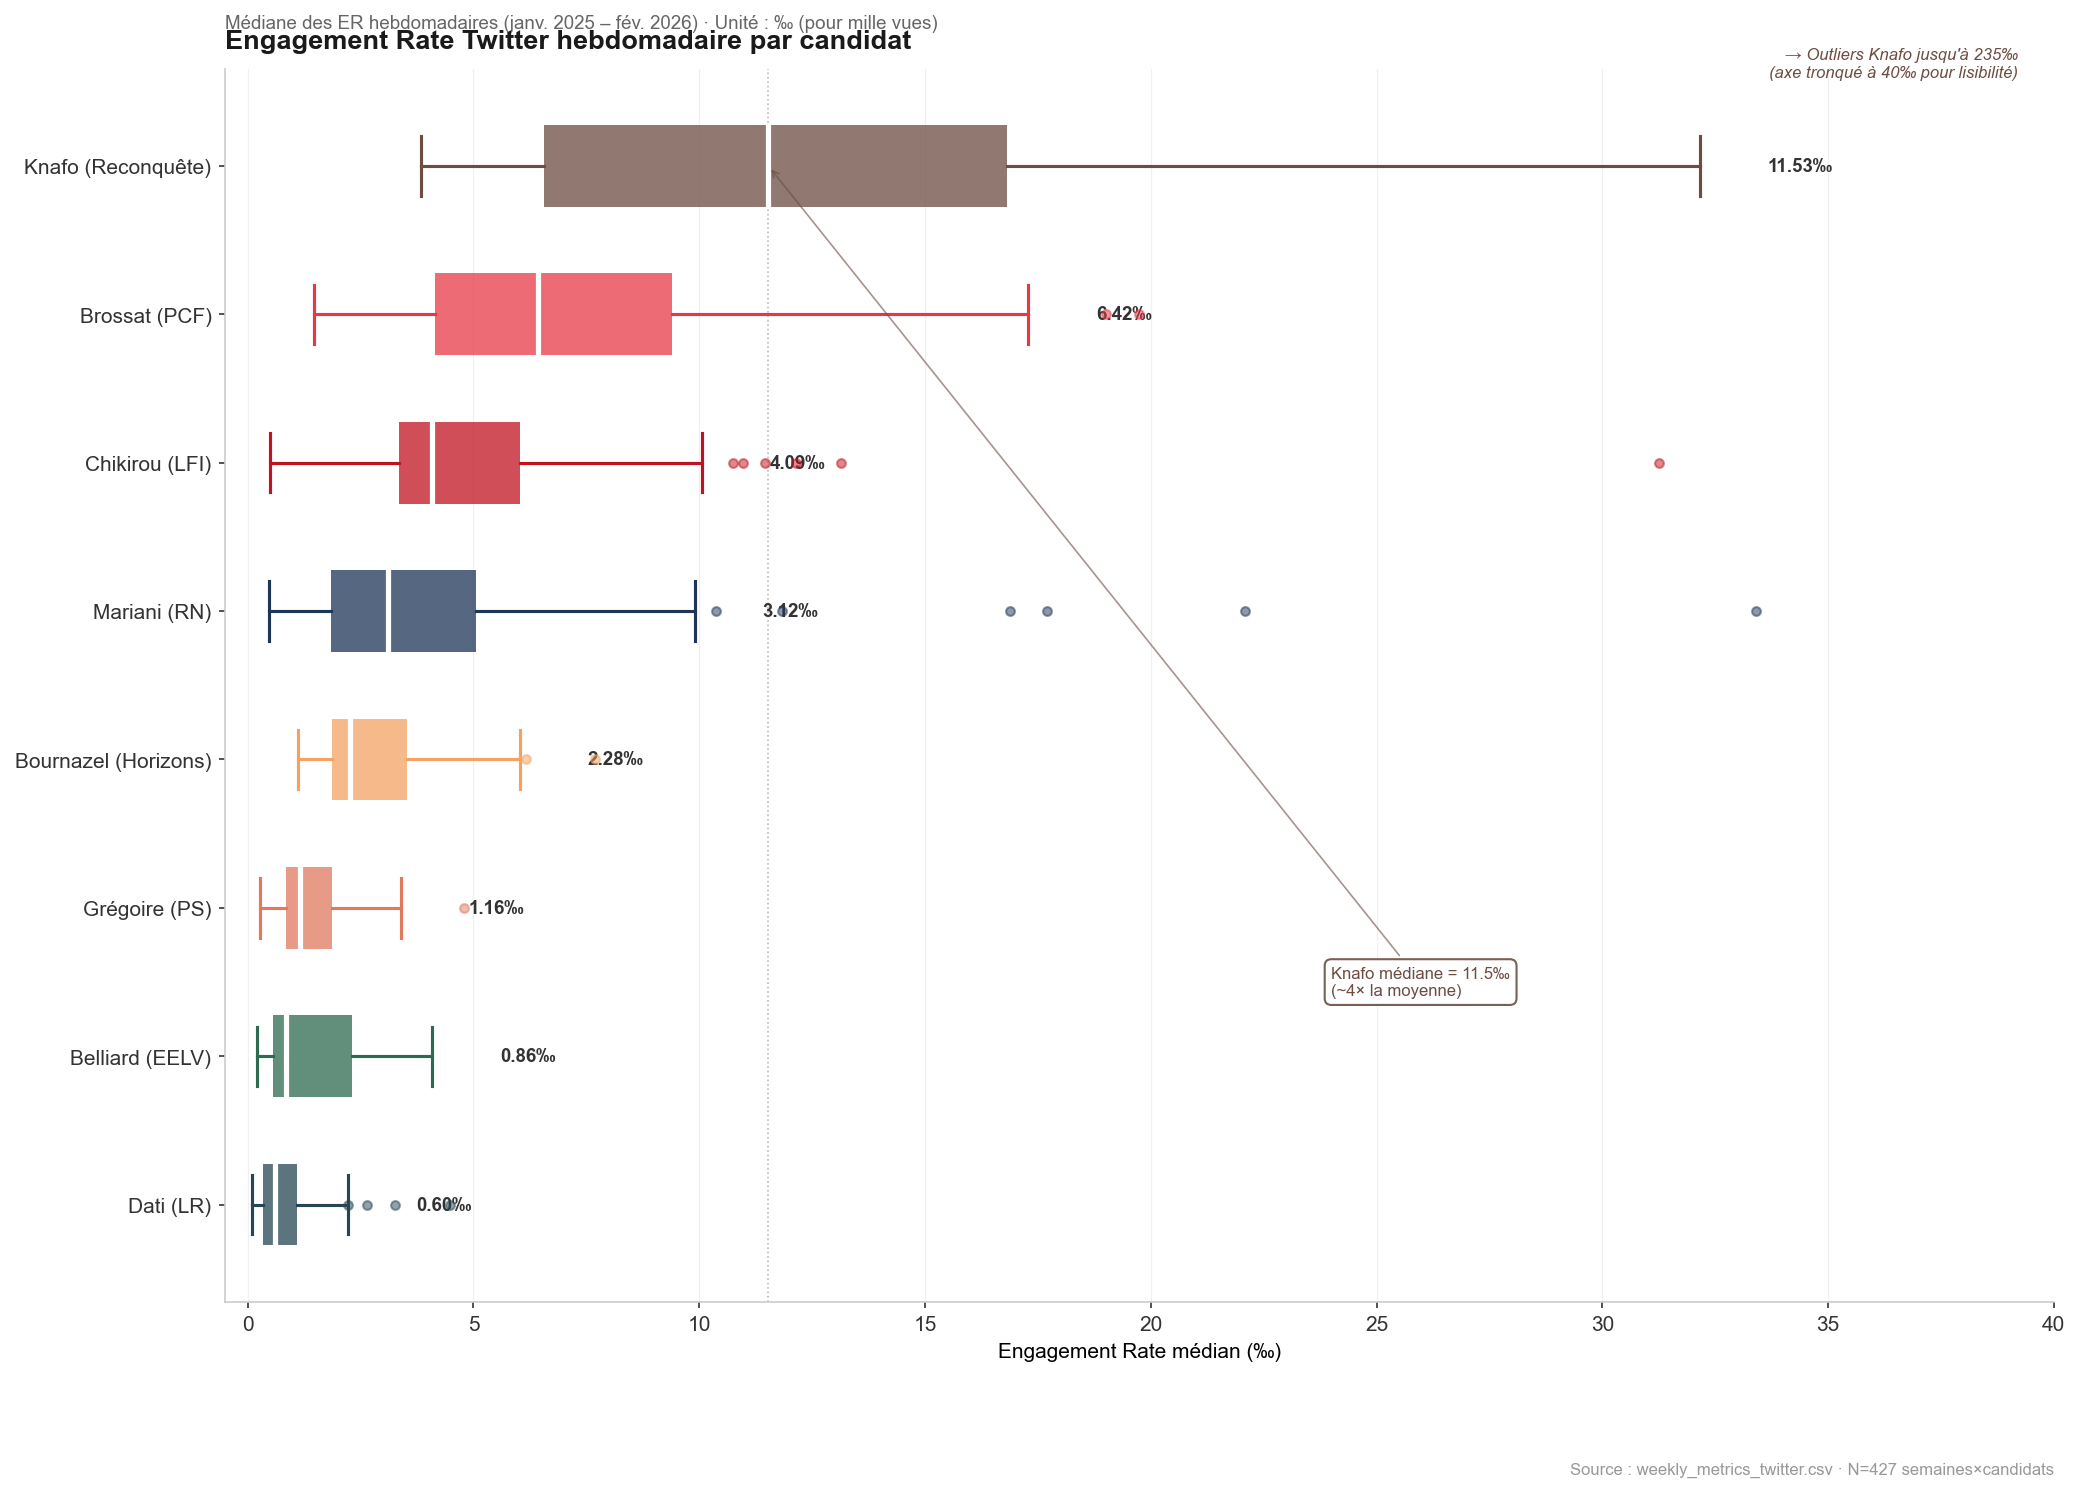


ER médian (‰) par candidat :
           median    mean     std
key                              
Knafo      11.532  32.657  54.388
Brossat     6.423   7.314   3.991
Chikirou    4.093   5.575   4.557
Mariani     3.118   4.890   5.885
Bournazel   2.278   2.767   1.423
Gregoire    1.161   1.452   0.896
Belliard    0.857   1.503   1.166
Dati        0.603   0.897   0.820

Note : axe tronqué à 40‰ — outlier Knafo max = 234.9‰
Rapport mean/median Knafo = 2.83x → distribution très asymétrique (quelques pics viraux)


In [24]:
# ============================================================
# CELLULE 3 — Engagement Rate comparatif : boxplot horizontal
#             ER hebdomadaire par candidat (en ‰ = × 1000)
# ============================================================

from scipy import stats

# ── Données : er_median Twitter en ‰ pour lisibilité ─────────
tw["er_pct"] = tw["er_median"] * 1000  # ratio → ‰

# Ordre : médiane croissante
ordre_er = tw.groupby("key")["er_pct"].median().sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(14, 10))

# Clip de l'axe pour lisibilité (outliers de Knafo exclus du cadre)
CLIP = 40

for i, cand in enumerate(ordre_er):
    data = tw.loc[tw["key"] == cand, "er_pct"].dropna()
    med = float(data.median())
    q1, q3 = float(data.quantile(0.25)), float(data.quantile(0.75))
    iqr = q3 - q1
    lo = max(float(data.min()), q1 - 1.5 * iqr)
    hi = min(float(data.max()), q3 + 1.5 * iqr)

    color = COLORS[str(cand)]

    # Boîte IQR
    ax.barh(i, q3 - q1, left=q1, height=0.55, color=color, alpha=0.75, zorder=3)
    # Moustaches
    ax.plot([lo, q1], [i, i], color=color, lw=1.5, zorder=3)
    ax.plot([q3, hi], [i, i], color=color, lw=1.5, zorder=3)
    ax.plot([lo, lo], [i - 0.2, i + 0.2], color=color, lw=1.5, zorder=3)
    ax.plot([hi, hi], [i - 0.2, i + 0.2], color=color, lw=1.5, zorder=3)
    # Médiane
    ax.plot([med, med], [i - 0.27, i + 0.27], color="white", lw=2.5, zorder=4)

    # Outliers (seulement ceux dans la zone visible)
    outliers = data[(data < lo) | (data > hi)]
    outliers_visible = outliers[outliers <= CLIP]
    ax.scatter(outliers_visible.values, [i] * len(outliers_visible), color=color, s=18, zorder=5, alpha=0.5)

    # Label : médiane à droite de la boîte
    label_x = min(hi + 1.5, CLIP - 5)
    ax.text(
        label_x,
        i,
        f"{med:.2f}‰",
        va="center",
        ha="left",
        fontsize=9,
        color="#333333",
        fontweight="bold",
    )

# ── Axes et style ─────────────────────────────────────────────
ax.set_yticks(range(len(ordre_er)))
ax.set_yticklabels([SHORT_LABEL[str(c)].replace("\n", " ") for c in ordre_er], fontsize=10)

ax.set_xlim(left=-0.5, right=CLIP)

# Note sur les outliers tronqués
knafo_max = float(tw[tw["key"] == "Knafo"]["er_pct"].max())
ax.text(CLIP * 0.98, len(ordre_er) - 0.2,
        f'→ Outliers Knafo jusqu\'à {knafo_max:.0f}‰\n'
        f'   (axe tronqué à {CLIP}‰ pour lisibilité)',
        ha='right', va='top', fontsize=8, color='#6D4C41',
        style='italic')

swiss_style(
    ax,
    title="Engagement Rate Twitter hebdomadaire par candidat",
    subtitle="Médiane des ER hebdomadaires (janv. 2025 – fév. 2026) · Unité : ‰ (pour mille vues)",
    source="Source : weekly_metrics_twitter.csv · N=427 semaines×candidats",
    grid_axis="x",
)

# Ajuster le sous-titre pour qu'il soit bien positionné sous le titre
fig = ax.get_figure()
for text in fig.texts:
    if "Médiane des ER" in text.get_text():
        current_pos = text.get_position()
        text.set_position((current_pos[0], current_pos[1] - 0.03))

ax.set_xlabel("Engagement Rate médian (‰)", fontsize=10)

# Annotation Knafo
knafo_med = float(tw.loc[tw["key"] == "Knafo", "er_pct"].median())
ax.axvline(
    knafo_med, color="#6D4C41", linewidth=0.8, linestyle=":", alpha=0.4, zorder=1
)

# Annotation dans une zone libre
ordre_er_list = list(ordre_er)
knafo_idx = ordre_er_list.index("Knafo") if "Knafo" in ordre_er_list else len(ordre_er_list) - 1
ax.annotate(
    f"Knafo médiane = {knafo_med:.1f}‰\n(5,1× la médiane des 7 autres)",
    xy=(min(knafo_med, CLIP - 2), knafo_idx),
    xytext=(CLIP * 0.6, 1.5),
    fontsize=8,
    color="#6D4C41",
    va="center",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#6D4C41", alpha=0.9),
    arrowprops=None,
)

plt.tight_layout()
plt.savefig(OUT / "A1_C3_boxplot_ER.png", dpi=200, bbox_inches="tight")
plt.show()

# Sortie texte
print(f"\n{'='*50}")
print("ER médian (‰) par candidat :")
stats_df = tw.groupby('key')['er_pct'].agg(['median', 'mean', 'std']).round(3)
stats_df = stats_df.sort_values('median', ascending=False)
print(stats_df.to_string())
print(f"\nNote : axe tronqué à {CLIP}‰ — outlier Knafo max = {knafo_max:.1f}‰")
knafo_mean = float(tw[tw['key'] == 'Knafo']['er_pct'].mean())
print(f"Rapport mean/median Knafo = {knafo_mean / knafo_med:.2f}x → distribution très asymétrique (quelques pics viraux)")

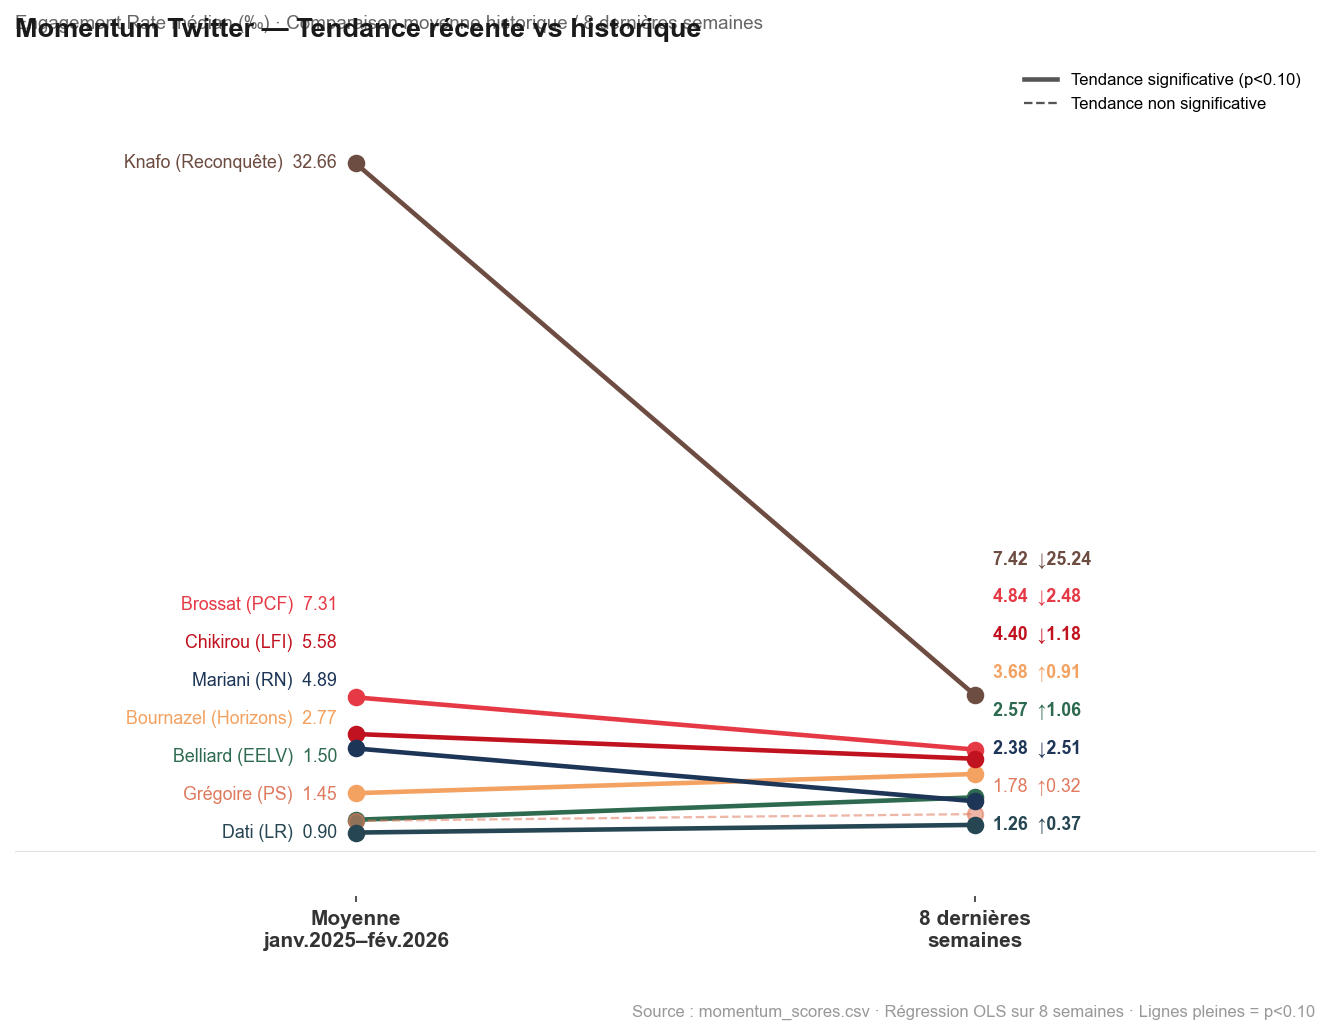

✓ Figure sauvegardée

Momentum Twitter (trié par p-value) :
      key  hist_mean  last_8w_er_pct  momentum_slope  r_squared  p_value direction
  Brossat     7.3141           4.837         -0.0005     0.5543   0.0341    baisse
 Belliard     1.5031           2.567         -0.0003     0.5489   0.0355    baisse
     Dati     0.8968           1.262         -0.0002     0.5304   0.0405    baisse
Bournazel     2.7668           3.677         -0.0002     0.4708   0.0602    baisse
 Chikirou     5.5752           4.400         -0.0009     0.4694   0.0608    baisse
    Knafo    32.6573           7.422         -0.0011     0.4690   0.0609    baisse
  Mariani     4.8901           2.384         -0.0006     0.4045   0.0901    baisse
 Gregoire     1.4519           1.775          0.0001     0.0830   0.4890    hausse


In [25]:
# ============================================================
# CELLULE 4 — Momentum : slope chart historical vs 8 dernières semaines
#             Twitter uniquement (IG exclu : Bournazel aberrant)
# ============================================================

mom_tw = mom[mom["platform"] == "twitter"].copy()

# ── Calculer la moyenne historique par candidat ───────────────
hist_means = tw.groupby("key")["er_pct"].mean().to_frame("hist_mean").reset_index()
mom_tw = mom_tw.merge(hist_means, on="key")
mom_tw["last_8w_er_pct"] = mom_tw["last_8w_mean_er"] * 1000

# ── Figure : slope chart ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

x_left, x_right = 0, 1

# Collecter les positions Y pour éviter les chevauchements
left_positions = []
right_positions = []

for _, row in mom_tw.iterrows():
    cand = str(row["key"])
    color = COLORS[cand]
    y_l = float(row["hist_mean"])
    y_r = float(row["last_8w_er_pct"])
    left_positions.append((y_l, cand, color, row))
    right_positions.append((y_r, cand, color, row))

# Trier par position Y pour ajuster les chevauchements
left_positions.sort(key=lambda x: x[0])
right_positions.sort(key=lambda x: x[0])

# Fonction pour ajuster les positions et éviter les chevauchements
def adjust_label_positions(positions, min_gap=1.5):
    """Ajuste les positions Y des labels pour éviter les superpositions."""
    adjusted = []
    for i, (y, cand, color, row) in enumerate(positions):
        if adjusted and y - adjusted[-1][0] < min_gap:
            y = adjusted[-1][0] + min_gap
        adjusted.append((y, cand, color, row))
    return adjusted

left_adjusted = adjust_label_positions(left_positions, min_gap=1.8)
right_adjusted = adjust_label_positions(right_positions, min_gap=1.8)

# Créer des dictionnaires pour les positions ajustées
left_label_y = {cand: y_adj for y_adj, cand, _, _ in left_adjusted}
right_label_y = {cand: y_adj for y_adj, cand, _, _ in right_adjusted}

for _, row in mom_tw.iterrows():
    cand = str(row["key"])
    color = COLORS[cand]
    y_l = float(row["hist_mean"])
    y_r = float(row["last_8w_er_pct"])
    delta = y_r - y_l
    sig = row["p_value"] < 0.1  # seuil α=0.10 (n=8 points)

    lw = 2.2 if sig else 1.1
    ls = "-" if sig else "--"
    alpha = 1.0 if sig else 0.55

    ax.plot(
        [x_left, x_right], [y_l, y_r], color=color, lw=lw, ls=ls, alpha=alpha, zorder=3
    )
    ax.scatter([x_left, x_right], [y_l, y_r], color=color, s=55, zorder=4, alpha=alpha)

    # Positions ajustées pour les labels
    y_l_label = left_label_y.get(cand, y_l)
    y_r_label = right_label_y.get(cand, y_r)

    # Labels gauche
    ax.text(
        x_left - 0.03,
        y_l_label,
        f"{SHORT_LABEL[cand].replace(chr(10), ' ')}  {y_l:.2f}",
        ha="right",
        va="center",
        fontsize=8.5,
        color=color,
    )
    # Labels droite
    direction = "↑" if delta > 0 else "↓"
    ax.text(
        x_right + 0.03,
        y_r_label,
        f"{y_r:.2f}  {direction}{abs(delta):.2f}",
        ha="left",
        va="center",
        fontsize=8.5,
        color=color,
        fontweight="bold" if sig else "normal",
    )

# ── Axes ──────────────────────────────────────────────────────
# Ajuster l'échelle Y pour inclure toutes les valeurs avec marge
all_y = list(mom_tw["hist_mean"]) + list(mom_tw["last_8w_er_pct"])
y_min = min(all_y) - 3
y_max = max(all_y) + 5
ax.set_ylim(y_min, y_max)

ax.set_xlim(-0.55, 1.55)
ax.set_xticks([x_left, x_right])
ax.set_xticklabels(
    ["Moyenne\njanv.2025–fév.2026", "8 dernières\nsemaines"],
    fontsize=10,
    fontweight="bold",
)
ax.yaxis.set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_facecolor("white")
ax.figure.set_facecolor("white")

# Zone de référence horizontale à 0
ax.axhline(0, color="#E0E0E0", lw=0.5)

# Légende lignes pleines vs pointillées
leg_handles = [
    Line2D(
        [0], [0], color="#555", lw=2.2, ls="-", label="Tendance significative (p<0.10)"
    ),
    Line2D([0], [0], color="#555", lw=1.1, ls="--", label="Tendance non significative"),
]
ax.legend(handles=leg_handles, loc="upper right", fontsize=8, frameon=False)

swiss_style(
    ax,
    title="Momentum Twitter — Tendance récente vs historique",
    subtitle="Engagement Rate médian (‰) · Comparaison moyenne historique / 8 dernières semaines",
    source="Source : momentum_scores.csv · Régression OLS sur 8 semaines · Lignes pleines = p<0.10",
)

plt.tight_layout()
plt.savefig(OUT / "A1_C4_momentum_slope.png", dpi=200, bbox_inches="tight")
plt.show()
print("✓ Figure sauvegardée")
print("\nMomentum Twitter (trié par p-value) :")
print(
    mom_tw[
        [
            "key",
            "hist_mean",
            "last_8w_er_pct",
            "momentum_slope",
            "r_squared",
            "p_value",
            "direction",
        ]
    ]
    .sort_values(by="p_value")
    .round(4)
    .to_string(index=False)
)

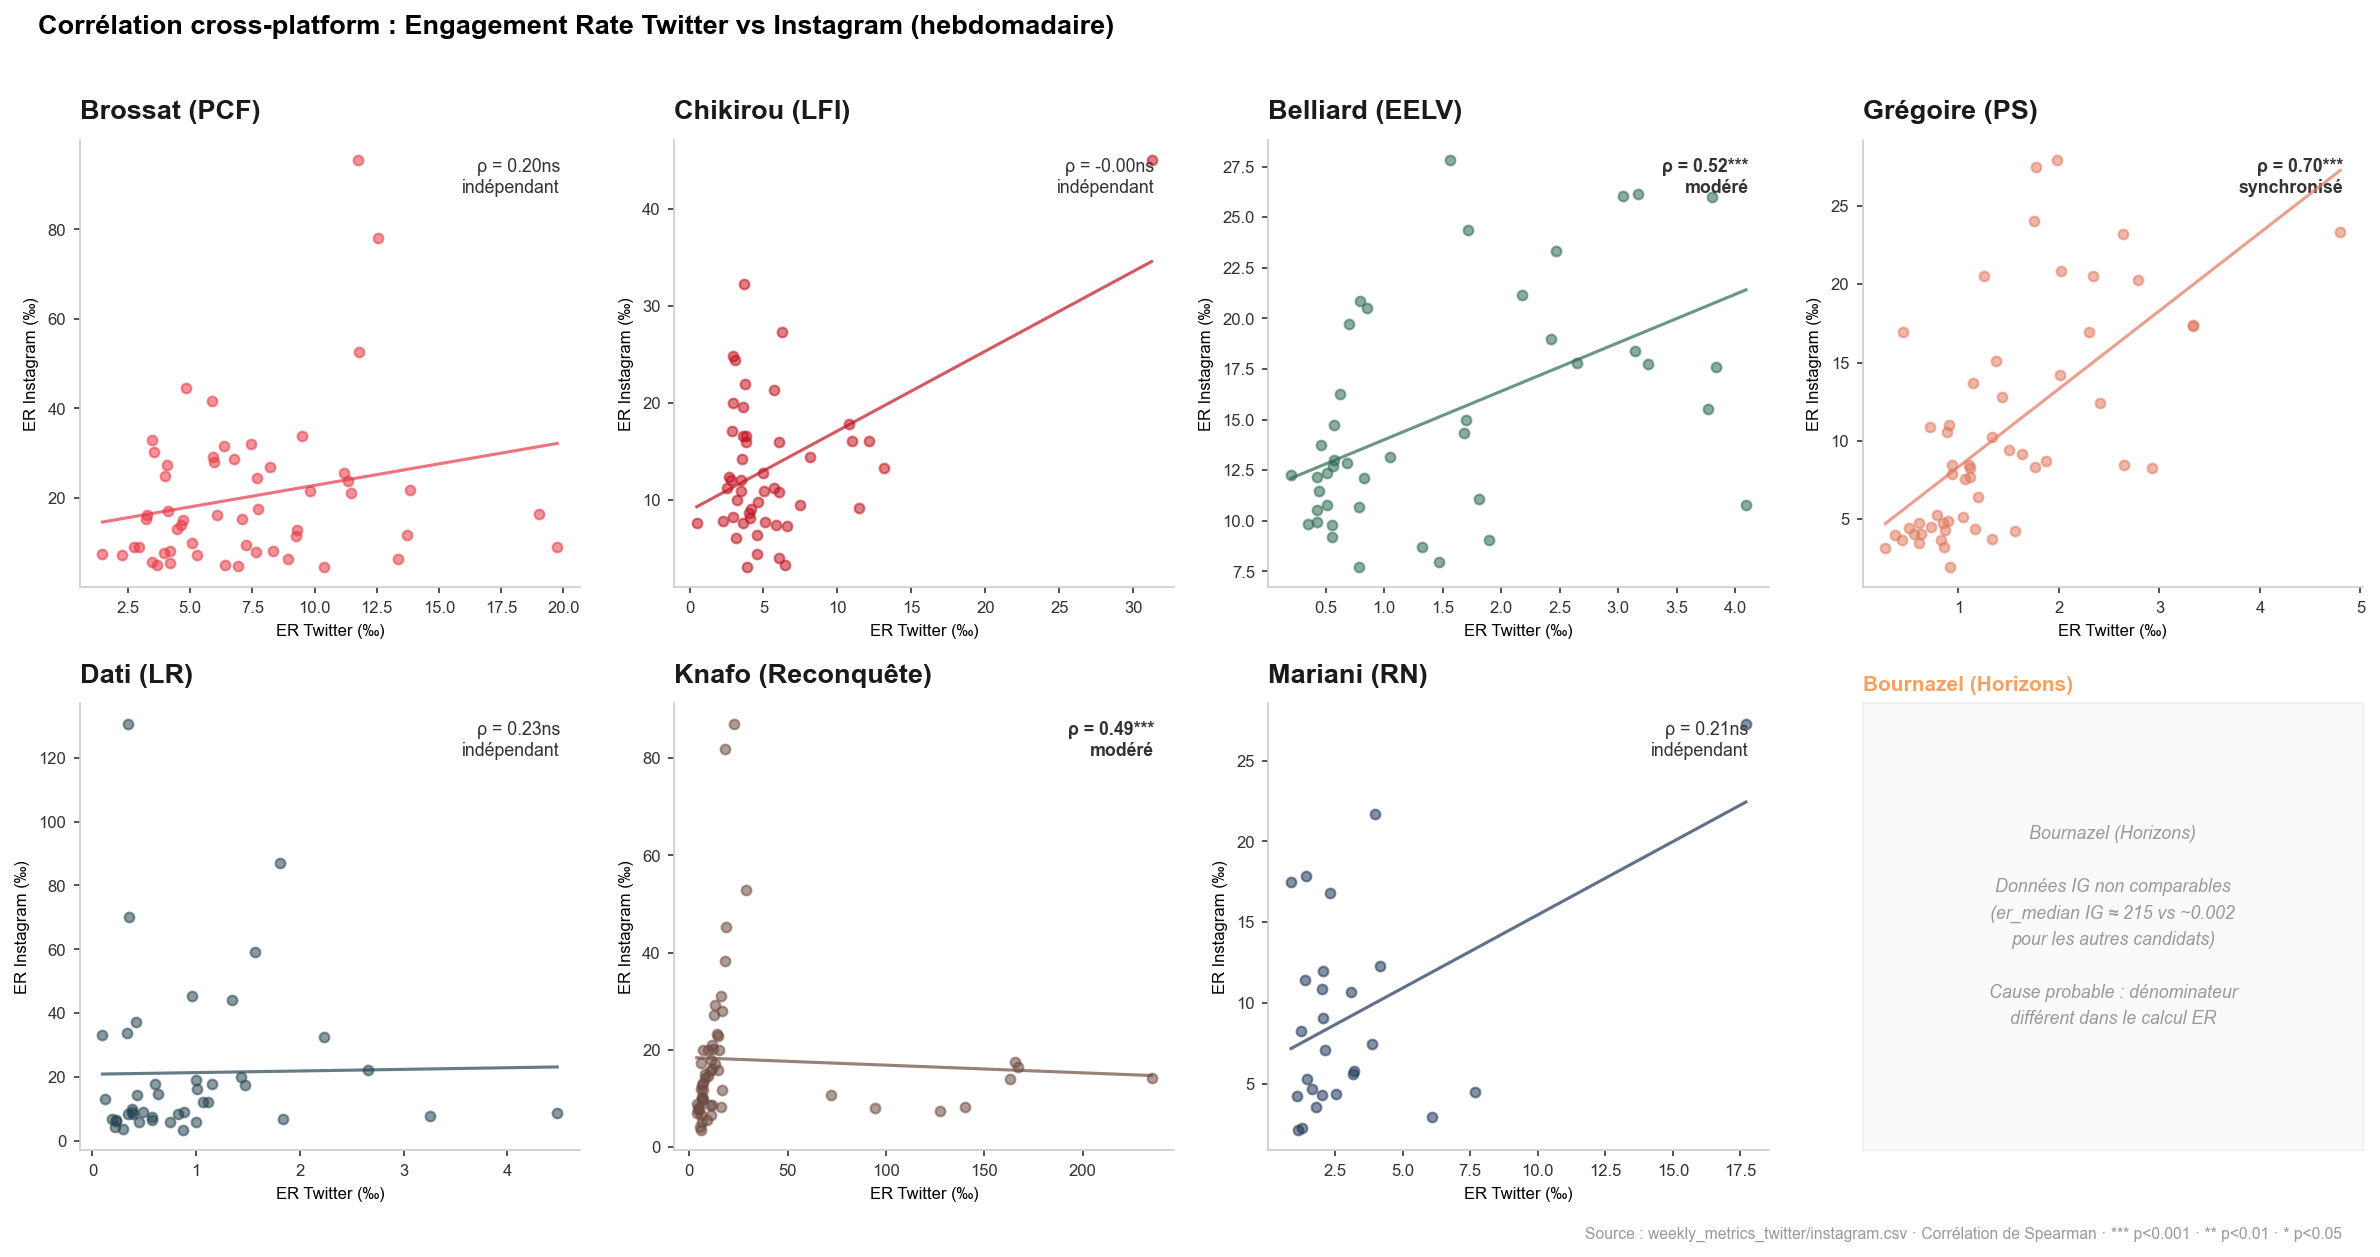

✓ Figure sauvegardée

Synchronie cross-platform Twitter ↔ Instagram :
          candidate_label  spearman_rho  p_value  n_weeks   synchrony
P-Y. Bournazel (Horizons)         0.821   0.0000       53 synchronisé
         E. Grégoire (PS)         0.699   0.0000       55 synchronisé
       D. Belliard (EELV)         0.516   0.0004       43      modéré
    S. Knafo (Reconquête)         0.493   0.0001       56      modéré
             R. Dati (LR)         0.235   0.1286       43 indépendant
          T. Mariani (RN)         0.210   0.3041       26 indépendant
         I. Brossat (PCF)         0.205   0.1330       55 indépendant
        S. Chikirou (LFI)        -0.004   0.9761       49 indépendant


In [26]:
# ============================================================
# CELLULE 5 — Corrélation cross-platform Twitter ↔ Instagram
#             Scatter hebdomadaire + corrélations de Spearman
# ============================================================

from scipy.stats import spearmanr

# ── Jointure Twitter × Instagram sur (candidate_id, year_week) ─
tw_ig = tw.merge(
    ig[["candidate_id", "year_week", "er_median"]],
    on=["candidate_id", "year_week"],
    suffixes=("_tw", "_ig"),
)
tw_ig["er_tw_pct"] = tw_ig["er_median_tw"] * 1000
tw_ig["er_ig_pct"] = tw_ig["er_median_ig"] * 1000

# Bournazel IG exclu : er_median IG ~215 (vs ~0.002 pour les autres)
# → ER calculé avec un dénominateur différent (aberrant confirmé : momentum_slope = -10.46)
tw_ig = tw_ig[tw_ig["key"] != "Bournazel"]

# ── Corrélations par candidat (depuis fichier pré-calculé) ────
cor_tw_ig = cor[
    (cor["platform_1"] == "twitter") & (cor["platform_2"] == "instagram")
].copy()

# ── Figure : small multiples 2×4 ─────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

ORDER_SCATTER = [
    "Brossat",
    "Chikirou",
    "Belliard",
    "Gregoire",
    "Dati",
    "Knafo",
    "Mariani",
]

for i, cand in enumerate(ORDER_SCATTER):
    ax = axes[i]
    sub = tw_ig[tw_ig["key"] == cand]

    ax.scatter(
        sub["er_tw_pct"],
        sub["er_ig_pct"],
        color=COLORS[cand],
        alpha=0.55,
        s=22,
        zorder=3,
    )

    # Ligne de tendance OLS
    if len(sub) > 5:
        x_sorted = sub["er_tw_pct"].sort_values()
        slope, intercept, *_ = stats.linregress(sub["er_tw_pct"], sub["er_ig_pct"])
        ax.plot(
            x_sorted,
            slope * x_sorted + intercept,
            color=COLORS[cand],
            lw=1.5,
            alpha=0.7,
            zorder=4,
        )

    # Récupérer Spearman pré-calculé
    row_cor = cor_tw_ig[
        cor_tw_ig["candidate_id"].str.contains(
            cand.lower()
            .replace("gregoire", "gregoire")
            .replace("Gregoire", "gregoire"),
            case=False,
        )
    ]
    if len(row_cor):
        rho = row_cor.iloc[0]["spearman_rho"]
        pv = row_cor.iloc[0]["p_value"]
        sync = row_cor.iloc[0]["synchrony"]
        stars = (
            "***" if pv < 0.001 else "**" if pv < 0.01 else "*" if pv < 0.05 else "ns"
        )
        ax.text(
            0.96,
            0.96,
            f"ρ = {rho:.2f}{stars}\n{sync}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=8.5,
            color="#333333",
            fontweight="bold" if pv < 0.05 else "normal",
        )

    swiss_style(ax, title=SHORT_LABEL[cand].replace("\n", " "), grid_axis=None)
    ax.set_xlabel("ER Twitter (‰)", fontsize=8)
    ax.set_ylabel("ER Instagram (‰)", fontsize=8)
    ax.tick_params(labelsize=8)
    ax.set_facecolor("white")

# Subplot 8 (index 7) : note Bournazel
ax_b = axes[7]
ax_b.set_facecolor("#FAFAFA")
ax_b.text(0.5, 0.5,
    "Bournazel (Horizons)\n\nDonnées IG non comparables\n"
    "(er_median IG ≈ 215 vs ~0.002\npour les autres candidats)\n\n"
    "Cause probable : dénominateur\ndifférent dans le calcul ER",
    ha="center", va="center", transform=ax_b.transAxes,
    fontsize=8.5, color="#999999", style="italic", linespacing=1.6)
ax_b.set_title("Bournazel (Horizons)", fontsize=10, fontweight="bold",
               loc="left", color="#F4A261")
for spine in ax_b.spines.values():
    spine.set_color("#EEEEEE")
ax_b.set_xticks([])
ax_b.set_yticks([])

fig.suptitle(
    "Corrélation cross-platform : Engagement Rate Twitter vs Instagram (hebdomadaire)",
    fontsize=13,
    fontweight="bold",
    x=0.02,
    ha="left",
    y=1.01,
)
fig.text(
    0.98,
    -0.01,
    "Source : weekly_metrics_twitter/instagram.csv · Corrélation de Spearman · *** p<0.001 · ** p<0.01 · * p<0.05",
    ha="right",
    fontsize=7.5,
    color="#999999",
)

plt.tight_layout()
plt.savefig(OUT / "A1_C5_crossplatform.png", dpi=200, bbox_inches="tight")
plt.show()
print("✓ Figure sauvegardée")
print("\nSynchronie cross-platform Twitter ↔ Instagram :")
print(
    cor_tw_ig[["candidate_label", "spearman_rho", "p_value", "n_weeks", "synchrony"]]
    .sort_values("spearman_rho", ascending=False)
    .to_string(index=False)
)

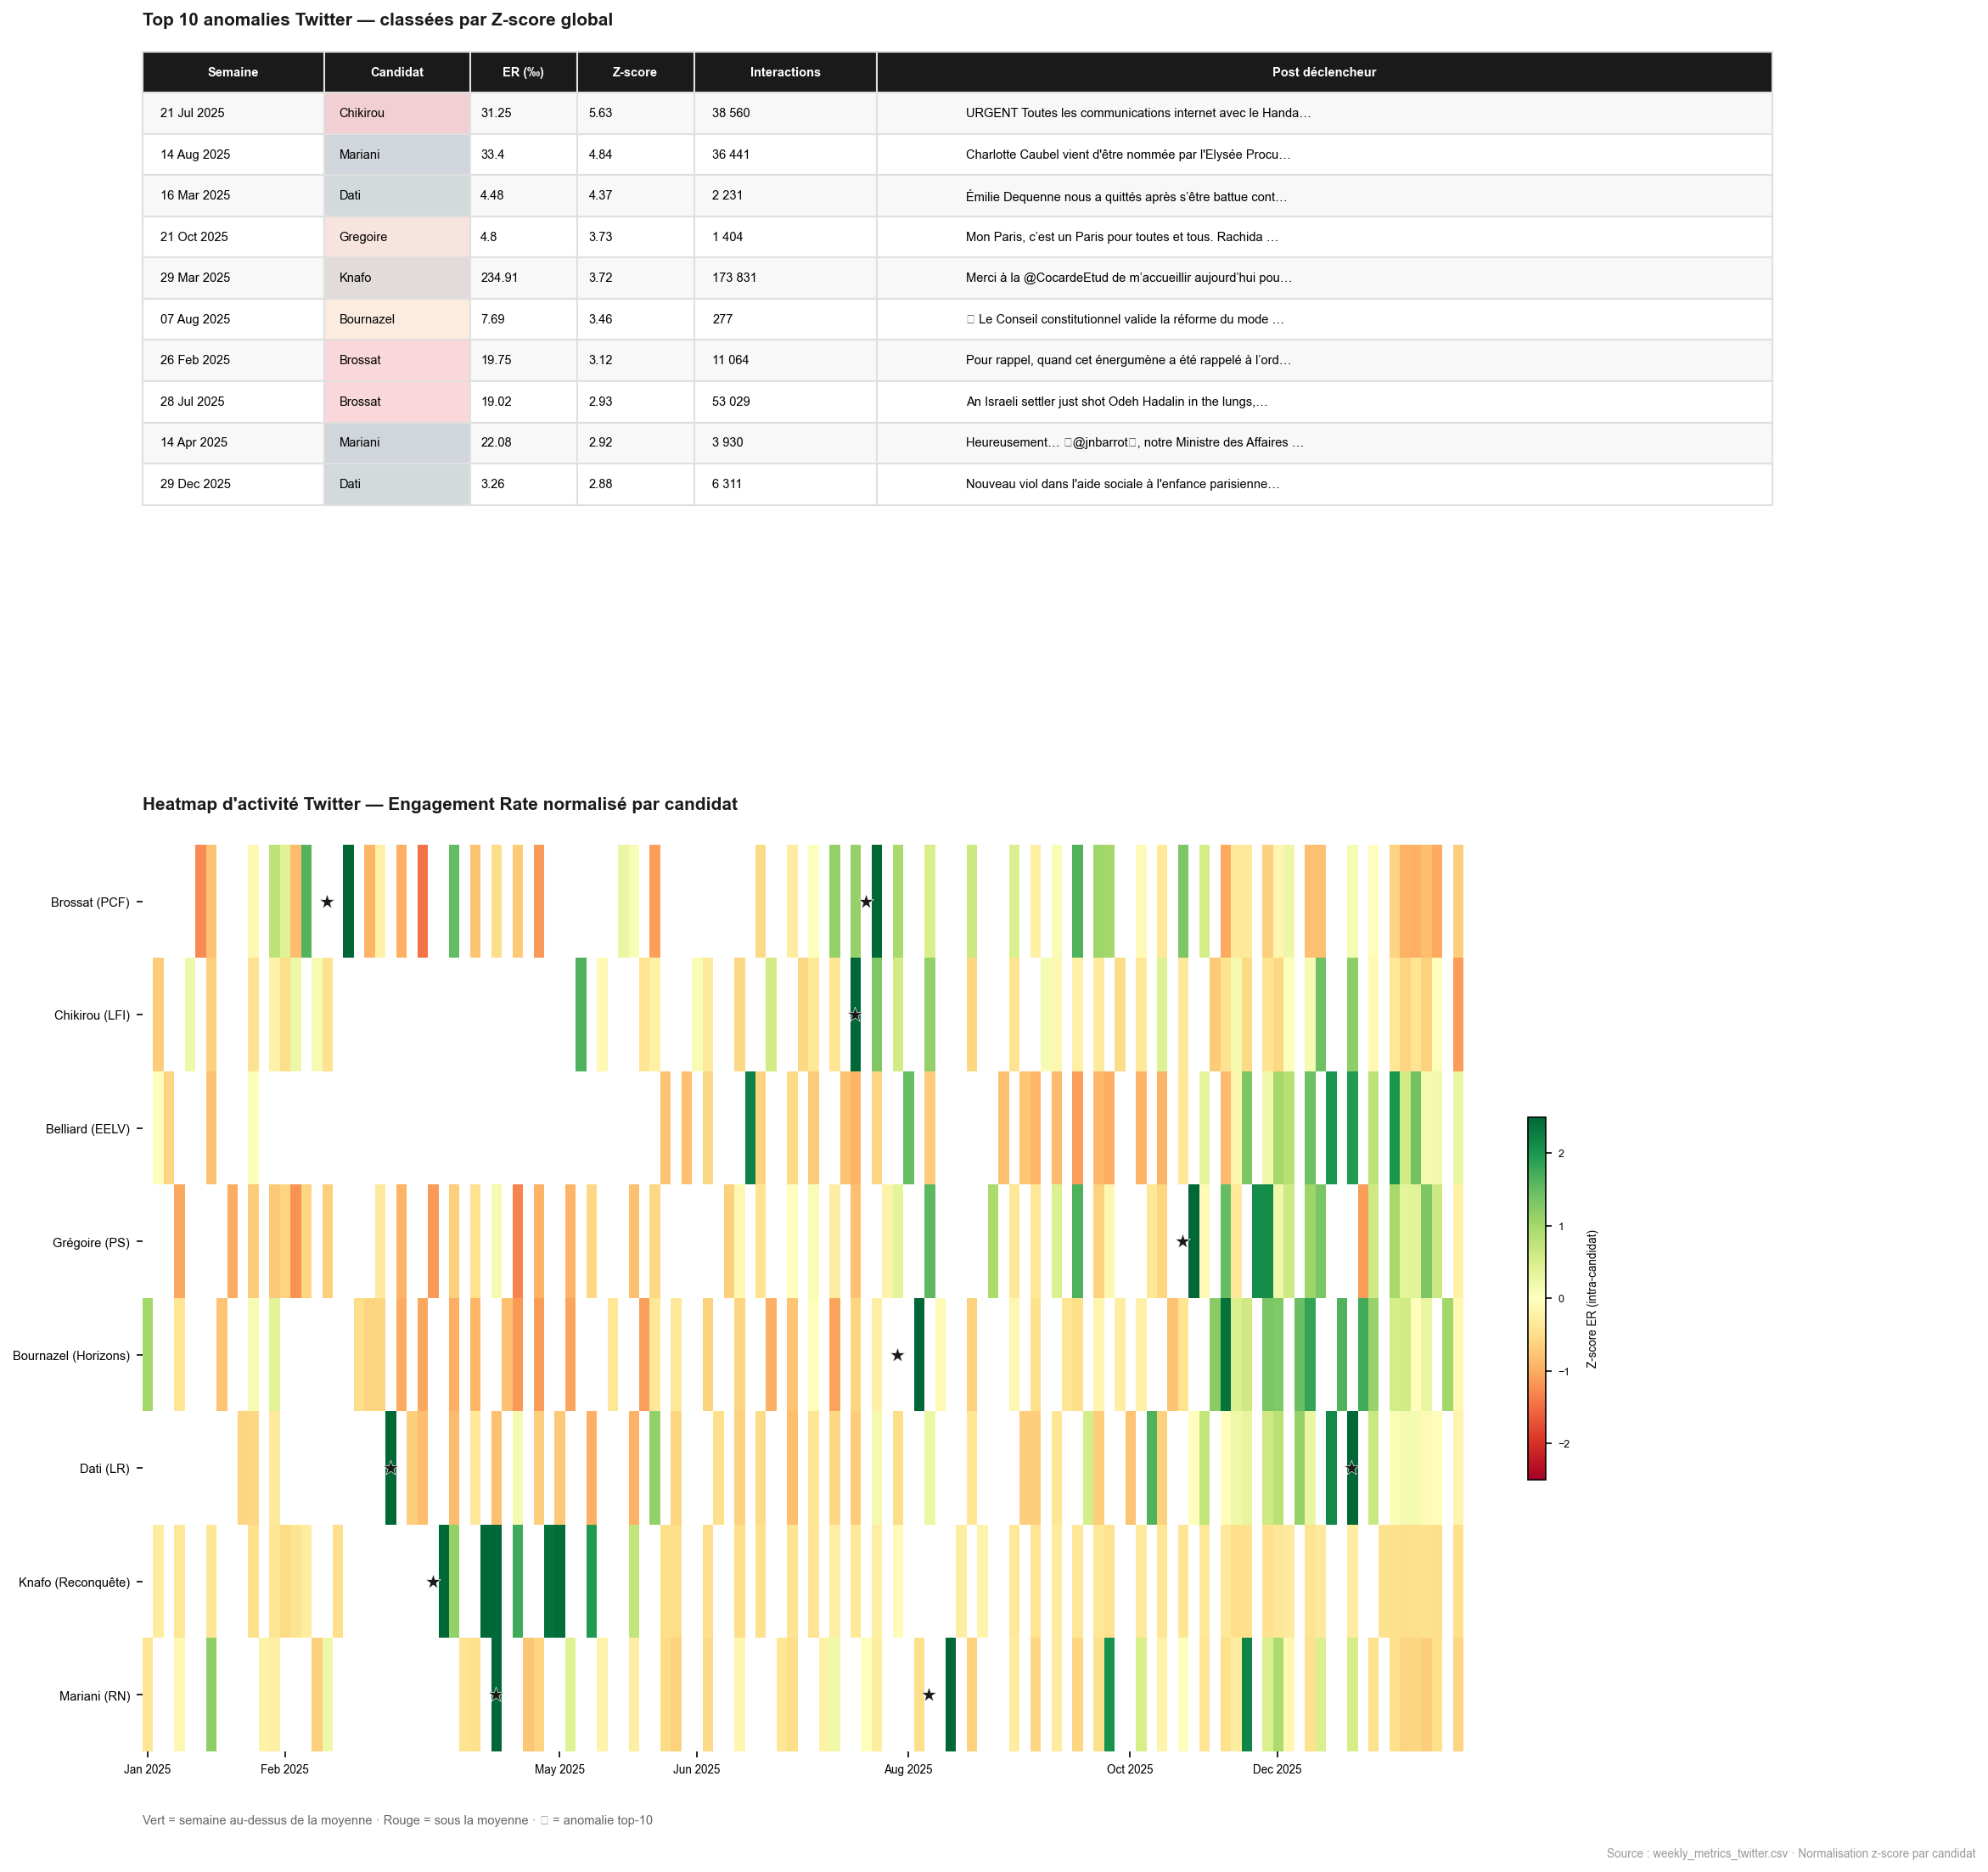

✓ Figure sauvegardée
✓ Export anomalies → outputs\A1_anomalies_top10.csv


In [27]:
# ============================================================
# CELLULE 6 — Anomalies : top-10 tableau + heatmap semaine×candidat
# ============================================================

fig = plt.figure(figsize=(16, 15))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 2], hspace=0.5)

# ── Panel haut : top-10 anomalies Twitter ────────────────────
ax_tab = fig.add_subplot(gs[0])
ax_tab.axis("off")

ano_tw = ano[ano["platform"] == "twitter"].copy()
top10 = (
    ano_tw.sort_values("z_global", ascending=False)
    .drop_duplicates("week_start")
    .head(10)[
        [
            "week_start",
            "key",
            "er_median",
            "z_score",
            "z_global",
            "top_post_engagement",
            "top_post_text",
        ]
    ]
    .copy()
)
top10["er_‰"] = (top10["er_median"] * 1000).round(2)
top10["z_global"] = top10["z_global"].round(2)
top10["engagement"] = top10["top_post_engagement"].apply(
    lambda x: f"{int(x):,}".replace(",", " ") if pd.notna(x) else "-"
)
top10["semaine"] = top10["week_start"].dt.strftime("%d %b %Y")
top10["extrait"] = top10["top_post_text"].str[:55] + "…"

table_data = top10[
    ["semaine", "key", "er_‰", "z_global", "engagement", "extrait"]
].values.tolist()
col_labels = [
    "Semaine",
    "Candidat",
    "ER (‰)",
    "Z-score",
    "Interactions",
    "Post déclencheur",
]

tbl = ax_tab.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc="left",
    loc="center",
    bbox=[0, 0, 1, 1],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(7)

# Couleurs de ligne par candidat
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("#E0E0E0")
    cell.set_height(0.075)
    if row == 0:
        cell.set_facecolor("#1a1a1a")
        cell.set_text_props(color="white", fontweight="bold")
    elif col == 1 and row > 0:
        cand_key = table_data[row - 1][1]
        cell.set_facecolor(COLORS.get(cand_key, "#FFFFFF") + "33")  # 20% opacity
    else:
        cell.set_facecolor("#FFFFFF" if row % 2 == 0 else "#F8F8F8")

# Largeurs colonnes
for col_idx in range(len(col_labels)):
    tbl.auto_set_column_width(col_idx)

ax_tab.set_title(
    "Top 10 anomalies Twitter — classées par Z-score global",
    fontsize=10,
    fontweight="bold",
    loc="left",
    pad=15,
    color="#1a1a1a",
)

# ── Panel bas : heatmap semaine × candidat ────────────────────
ax_heat = fig.add_subplot(gs[1])

# Pivot : er_median × (semaine, candidat), normalisé par candidat (z-score)
pivot_heat = tw.pivot_table(
    index="week_start", columns="key", values="er_median", aggfunc="median"
).reindex(columns=ORDRE)
# Normalisation intra-candidat pour comparer les profils
pivot_norm = pivot_heat.apply(lambda col: (col - col.mean()) / col.std(), axis=0)

im = ax_heat.imshow(
    pivot_norm.T.values,
    aspect="auto",
    cmap="RdYlGn",
    vmin=-2.5,
    vmax=2.5,
    interpolation="nearest",
)

# Axes Y avec espacement
ax_heat.set_yticks(range(len(ORDRE)))
ax_heat.set_yticklabels([SHORT_LABEL[c].replace("\n", " ") for c in ORDRE], fontsize=7)

# Axe X : une graduation tous les 4 mois pour éviter superposition
week_dates = pivot_norm.index.to_list()
months_idx = [i for i, d in enumerate(week_dates) if d.day <= 7]
# Filtrer pour ne garder qu'un mois sur 4 afin d'éviter la superposition
months_idx_filtered = months_idx[::4]
months_lbl = [week_dates[i].strftime("%b %Y") for i in months_idx_filtered]
ax_heat.set_xticks(months_idx_filtered)
ax_heat.set_xticklabels(months_lbl, fontsize=6.5, ha="center", rotation=0)

# Superposer les anomalies top-10 avec décalage pour éviter les superpositions
from collections import Counter
anomaly_positions = []
for _, row in top10.iterrows():
    if row["key"] in ORDRE:
        y_pos = ORDRE.index(row["key"])
        x_candidates = [
            i
            for i, d in enumerate(week_dates)
            if abs((d - row["week_start"]).days) <= 4
        ]
        if x_candidates:
            anomaly_positions.append((x_candidates[0], y_pos, row["key"]))

# Compter les superpositions par (x, y) et appliquer un léger offset
pos_counter = Counter()
for x_pos, y_pos, cand_key in anomaly_positions:
    count = pos_counter[(x_pos, y_pos)]
    # Offset horizontal léger pour les superpositions
    x_offset = count * 0.5
    ax_heat.scatter(
        x_pos + x_offset,
        y_pos,
        marker="*",
        s=80,
        color="#1a1a1a",
        zorder=5,
        linewidths=0.3,
        edgecolors="white",
    )
    pos_counter[(x_pos, y_pos)] += 1

# Colorbar avec espacement suffisant
cbar = plt.colorbar(im, ax=ax_heat, shrink=0.4, pad=0.04, aspect=20)
cbar.set_label("Z-score ER (intra-candidat)", fontsize=6.5, labelpad=10)
cbar.ax.tick_params(labelsize=6)

# Titre principal de la heatmap avec espacement
ax_heat.set_title(
    "Heatmap d'activité Twitter — Engagement Rate normalisé par candidat",
    fontsize=10,
    fontweight="bold",
    loc="left",
    pad=20,
    color="#1a1a1a",
)

# Sous-titre séparé avec position calculée pour éviter superposition
ax_heat.text(
    0,
    -0.08,
    "Vert = semaine au-dessus de la moyenne · Rouge = sous la moyenne · ★ = anomalie top-10",
    fontsize=7,
    color="#666666",
    ha="left",
    transform=ax_heat.transAxes,
)

# Source en bas avec marge suffisante
fig.text(
    0.98,
    0.005,
    "Source : weekly_metrics_twitter.csv · Normalisation z-score par candidat",
    fontsize=6.5,
    color="#999999",
    ha="right",
)

ax_heat.spines["left"].set_visible(False)
ax_heat.spines["bottom"].set_visible(False)
ax_heat.spines["top"].set_visible(False)
ax_heat.spines["right"].set_visible(False)

# Ajuster les marges globales
plt.subplots_adjust(left=0.08, right=0.88, top=0.95, bottom=0.06)

plt.savefig(OUT / "A1_C6_anomalies_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()
print("✓ Figure sauvegardée")

# Export top-10 anomalies pour A2 et A3
top10_export = ano_tw.sort_values("z_global", ascending=False).head(10)[
    [
        "week_start",
        "key",
        "candidate_label",
        "year_week",
        "er_median",
        "z_global",
        "z_score",
        "top_post_engagement",
        "top_post_text",
    ]
]
top10_export.to_csv(OUT / "A1_anomalies_top10.csv", index=False)
print(f"✓ Export anomalies → {OUT / 'A1_anomalies_top10.csv'}")

In [28]:
# ============================================================
# CELLULE 7 — Résumé des findings A1 + exports pour A2/A3
# ============================================================

print("=" * 65)
print("FINDINGS A1 — DYNAMIQUE TEMPORELLE")
print("=" * 65)

# Finding 1 : dominance Knafo
knafo_er = tw[tw["key"] == "Knafo"]["er_pct"].median()
mean_er = tw[tw["key"] != "Knafo"]["er_pct"].median()
print(f"\nF1 — Knafo domine l'ER Twitter sur 13 mois")
print(f"     Médiane Knafo : {knafo_er:.2f}‰  vs  autres : {mean_er:.2f}‰")
print(f"     Ratio : {knafo_er/mean_er:.1f}× la médiane du reste du corpus")

# Finding 2 : momentum
n_decline = (mom_tw["p_value"] < 0.10).sum()
print(f"\nF2 — Déclin généralisé Twitter fin de période")
print(f"     {n_decline}/8 candidats en baisse significative (p<0.10)")
print(f"     Seule Grégoire : slope positive mais non significative (p=0.489)")

# Finding 3 : cross-platform
sync = cor_tw_ig[cor_tw_ig["synchrony"] == "synchronisé"]
indep = cor_tw_ig[cor_tw_ig["synchrony"] == "indépendant"]
print(f"\nF3 — Synchronie cross-platform hétérogène")
print(
    f"     Synchronisés (ρ>0.7) : {sync['candidate_label'].str.split('(').str[0].str.strip().tolist()}"
)
print(
    f"     Indépendants (ρ≈0)   : {indep['candidate_label'].str.split('(').str[0].str.strip().tolist()}"
)
print(f"     → Les candidats synchronisés ont une stratégie unifiée cross-platform")

# Finding 4 : anomalies
ano_by_cand = ano_tw.groupby("key").size().sort_values(ascending=False)
print(f"\nF4 — Distribution des anomalies par candidat :")
for cand, n in ano_by_cand.items():
    print(f"     {cand:<12} : {n} anomalies")

# Finding 5 : accélération de fin de campagne
last_12w = tw[tw["week_start"] >= "2025-11-01"]
first_12w = tw[tw["week_start"] < "2025-04-01"]
vol_recent = last_12w["volume"].sum()
vol_debut = first_12w["volume"].sum()
print(f"\nF5 — Intensification de l'activité en fin de période")
print(f"     Volume nov.2025–fév.2026 : {vol_recent:,} posts")
print(f"     Volume janv.–mars 2025   : {vol_debut:,} posts")
print(f"     Ratio : ×{vol_recent/vol_debut:.1f}")

# ── Export des anomalies dates → utilisé par A2 et A3 ─────────
ano_dates_export = ano_tw[
    [
        "week_start",
        "year_week",
        "key",
        "candidate_label",
        "z_global",
        "top_post_text",
        "top_post_engagement",
    ]
].copy()
ano_dates_export.to_csv(OUT / "A1_anomalies_for_A2_A3.csv", index=False)

# Export résumé ER par candidat
er_summary = (
    tw.groupby("key")
    .agg(
        er_median_pct=("er_pct", "median"),
        er_mean_pct=("er_pct", "mean"),
        er_std_pct=("er_pct", "std"),
        n_semaines=("year_week", "count"),
    )
    .round(4)
    .sort_values("er_median_pct", ascending=False)
)
er_summary.to_csv(OUT / "A1_er_summary.csv")

print(f"\n✓ Exports :")
print(f"   → {OUT / 'A1_anomalies_for_A2_A3.csv'}  (utilisé par A2 et A3)")
print(f"   → {OUT / 'A1_er_summary.csv'}")
print(f"   → {OUT / 'A1_anomalies_top10.csv'}")
print("\n✓ A1 TERMINÉ — 3 figures + 3 CSV exportés")

FINDINGS A1 — DYNAMIQUE TEMPORELLE

F1 — Knafo domine l'ER Twitter sur 13 mois
     Médiane Knafo : 11.53‰  vs  autres : 2.33‰
     Ratio : 5.0× la médiane du reste du corpus

F2 — Déclin généralisé Twitter fin de période
     7/8 candidats en baisse significative (p<0.10)
     Seule Grégoire : slope positive mais non significative (p=0.489)

F3 — Synchronie cross-platform hétérogène
     Synchronisés (ρ>0.7) : ['E. Grégoire', 'P-Y. Bournazel']
     Indépendants (ρ≈0)   : ['I. Brossat', 'R. Dati', 'S. Chikirou', 'T. Mariani']
     → Les candidats synchronisés ont une stratégie unifiée cross-platform

F4 — Distribution des anomalies par candidat :
     Knafo        : 7 anomalies
     Dati         : 6 anomalies
     Bournazel    : 5 anomalies
     Belliard     : 4 anomalies
     Gregoire     : 4 anomalies
     Mariani      : 4 anomalies
     Chikirou     : 3 anomalies
     Brossat      : 2 anomalies

F5 — Intensification de l'activité en fin de période
     Volume nov.2025–fév.2026 : 3,2

# A1 — Dynamiques Temporelles
**Paris Municipales 2026 — Pipeline v3**

Objectifs :
- Évolution hebdomadaire de l'engagement par plateforme
- Détection d'anomalies (pics viraux)
- Momentum et corrélations cross-platform
- Écosystème Grégoire

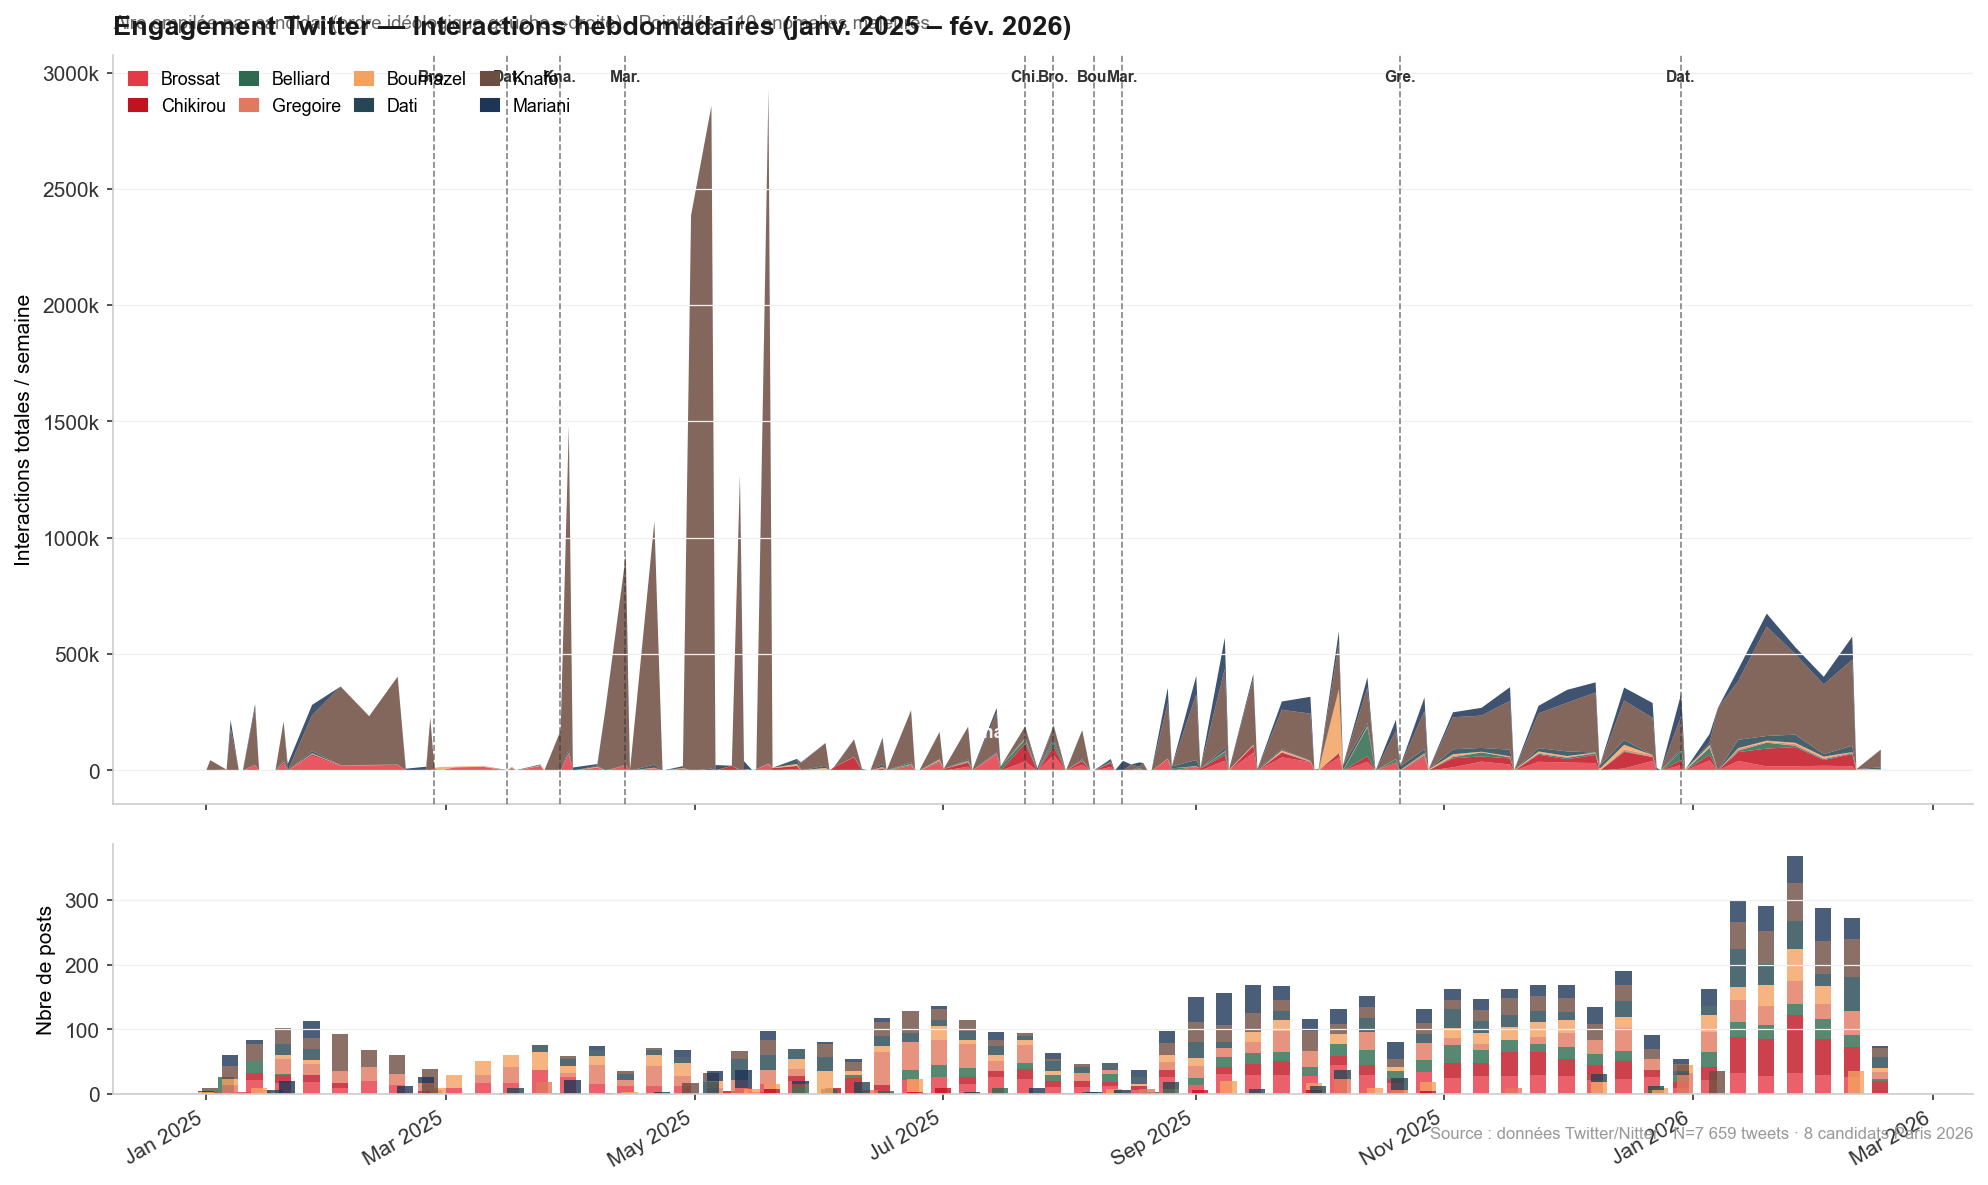

✓ Figure sauvegardée → outputs\A1_C2_timeline_engagement.png


In [29]:
# ============================================================
# CELLULE 2 — Timeline d'engagement Twitter : interactions hebdo
#             empilées par candidat, anomalies annotées
# ============================================================

fig, (ax_top, ax_bot) = plt.subplots(
    2,
    1,
    figsize=(16, 9),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08},
    sharex=True,
)

# ── Ordre des candidats : gauche → droite idéologique ────────
ORDRE = [
    "Brossat",
    "Chikirou",
    "Belliard",
    "Gregoire",
    "Bournazel",
    "Dati",
    "Knafo",
    "Mariani",
]

# ── Pivot : interactions totales par semaine × candidat ──────
pivot = (
    tw.pivot_table(
        index="week_start", columns="key", values="interactions_total", aggfunc="sum"
    )
    .reindex(columns=ORDRE)
    .fillna(0)
)

# ── Aire empilée (top panel) ──────────────────────────────────
bottom = np.zeros(len(pivot))
for cand in ORDRE:
    vals = pivot[cand].values
    ax_top.fill_between(
        pivot.index,
        bottom,
        bottom + vals,
        color=COLORS[cand],
        alpha=0.85,
        linewidth=0,
        label=cand,
    )
    bottom += vals

# ── Anomalies : lignes verticales + labels ───────────────────
ano_tw = ano[ano["platform"] == "twitter"].copy()
# Garder les 10 plus fortes par z_global
top_ano = (
    ano_tw.sort_values("z_global", ascending=False)
    .drop_duplicates("week_start")
    .head(10)
)

for _, row in top_ano.iterrows():
    ax_top.axvline(
        row["week_start"],
        color="#333333",
        linewidth=0.8,
        linestyle="--",
        alpha=0.6,
        zorder=5,
    )
    ax_top.text(
        row["week_start"],
        ax_top.get_ylim()[1] * 0.98,
        f"{row['key'][:3]}.",
        fontsize=7.5,
        color="#333333",
        ha="center",
        va="top",
        rotation=0,
        fontweight="bold",
    )

# ── Labels directs sur les bandes (évite la légende) ─────────
# Calculer la position médiane de chaque bande pour labeller
cumul = np.zeros(len(pivot))
for cand in ORDRE:
    vals = pivot[cand].values
    mid = cumul + vals / 2
    # Label au 75e percentile de la série temporelle
    idx_label = np.argsort(vals)[-len(vals) // 4]
    if vals[idx_label] > pivot.values.sum(axis=1).max() * 0.03:
        ax_top.text(
            pivot.index[idx_label],
            mid[idx_label],
            cand,
            fontsize=8.5,
            color="white",
            fontweight="bold",
            ha="center",
            va="center",
            alpha=0.9,
        )
    cumul += vals

swiss_style(
    ax_top,
    title="Engagement Twitter — Interactions hebdomadaires (janv. 2025 – fév. 2026)",
    subtitle="Aire empilée par candidat (ordre idéologique gauche→droite) · Pointillés = 10 anomalies majeures",
    grid_axis="y",
)
ax_top.set_ylabel("Interactions totales / semaine", fontsize=10)
ax_top.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k" if x >= 1000 else str(int(x)))
)

# ── Volume de posts (bottom panel) ───────────────────────────
pivot_vol = (
    tw.pivot_table(index="week_start", columns="key", values="volume", aggfunc="sum")
    .reindex(columns=ORDRE)
    .fillna(0)
)
bottom_v = np.zeros(len(pivot_vol))
for cand in ORDRE:
    ax_bot.bar(
        pivot_vol.index,
        pivot_vol[cand].values,
        bottom=bottom_v,
        color=COLORS[cand],
        width=4,
        alpha=0.8,
        linewidth=0,
    )
    bottom_v += pivot_vol[cand].values

swiss_style(
    ax_bot,
    title="",
    subtitle="",
    source="Source : données Twitter/Nitter · N=7 659 tweets · 8 candidats Paris 2026",
    grid_axis="y",
)
ax_bot.set_ylabel("Nbre de posts", fontsize=10)
ax_bot.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax_bot.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax_bot.xaxis.get_majorticklabels(), rotation=30, ha="right")

# ── Légende compacte ─────────────────────────────────────────
handles = [mpatches.Patch(color=COLORS[c], label=c) for c in ORDRE]
ax_top.legend(
    handles=handles,
    loc="upper left",
    ncol=4,
    fontsize=8.5,
    frameon=False,
    columnspacing=0.8,
    handlelength=1,
)

plt.tight_layout()
plt.savefig(OUT / "A1_C2_timeline_engagement.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"✓ Figure sauvegardée → {OUT / 'A1_C2_timeline_engagement.png'}")

## 1. Engagement Rate hebdomadaire par candidat (Twitter)

In [30]:
cand_order = tw.groupby("candidate_id")["engagement_rate"].median().sort_values(ascending=False).index.tolist()

fig = go.Figure()
for cand in cand_order:
    sub = tw[tw["candidate_id"] == cand].sort_values("week")
    fig.add_trace(go.Scatter(
        x=sub["week"], y=sub["engagement_rate"],
        mode="lines", name=SHORT.get(cand, cand),
        line=dict(color=CANDIDATE_COLORS.get(cand, "#888"), width=2),
        hovertemplate="%{x|%Y-%m-%d}<br>ER: %{y:.3f}%<extra>" + SHORT.get(cand, cand) + "</extra>",
    ))

fig.update_layout(
    template=TEMPLATE,
    title="Engagement Rate hebdomadaire — Twitter",
    xaxis_title="Semaine", yaxis_title="ER (%)",
    width=1000, height=500,
)
fig.show()


KeyError: 'Column not found: engagement_rate'

## 2. Anomalies détectées

In [ ]:
print(f"Total anomalies : {len(ano)}")
print(ano["type"].value_counts().to_string())
ano.sort_values("z_score", ascending=False).head(15)[[
    "candidate_id", "week", "type", "z_score", "metric", "value"
]]


## 3. Momentum (tendance récente vs historique)

In [ ]:
mom_sorted = mom.sort_values("momentum_score", ascending=False)
fig = px.bar(
    mom_sorted, x="candidate_id", y="momentum_score",
    color="candidate_id",
    color_discrete_map=CANDIDATE_COLORS,
    template=TEMPLATE,
    title="Score de momentum (Q1 2026 vs historique)",
    labels={"momentum_score": "Momentum", "candidate_id": "Candidat"},
)
fig.update_layout(showlegend=False, width=800, height=450)
fig.show()


## 4. Corrélations cross-platform

In [ ]:
cor.sort_values("spearman_rho", ascending=False)


## 5. Écosystème Grégoire

In [ ]:
eco.head(20)
